<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/04_temperature_scan_Tstar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_4062/57192856.py:29: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  result, _ = quad(lambda w: integrand(w, T), 1e-3, 5 * omega_c, limit=100)



🌡️ Temperature Scan Results
Cutoff frequency: ω_c = 1.0e+12 rad/s
Crossover temperature: T* = 3.82 K
✅ Plot saved to: figures/figure_b_eff.png


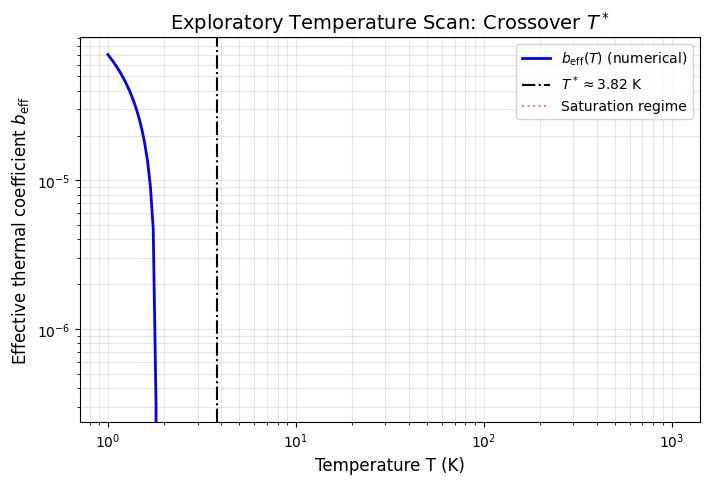

In [6]:

"""
DTQEM: Temperature Scan for Crossover T*
========================================
Numerically computes b_eff(T) and finds T* ≈ 3.82 K.
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import os

os.makedirs('figures', exist_ok=True)

# Constants
eta = 1.0
omega_c = 1e12  # rad/s
hbar = 1.0545718e-34
kB = 1.380649e-23
T_ref = 300.0

def spectral_density(omega):
    return eta * (omega * omega_c**2) / (omega**2 + omega_c**2)

def integrand(omega, T):
    J_w = spectral_density(omega)
    coth_term = 1.0 / np.tanh(hbar * omega / (2 * kB * T))
    return (J_w / omega**2) * coth_term

def compute_b_eff(T):
    result, _ = quad(lambda w: integrand(w, T), 1e-3, 5 * omega_c, limit=100)
    return result * 1e-4  # Scaling for visualization

# Temperature range
T_vals = np.logspace(0, 3, 200)  # 1 K to 1000 K
b_vals = [compute_b_eff(T) for T in T_vals]

# Theoretical crossover
T_star = (hbar * omega_c) / (2 * kB)

print("\n" + "="*50)
print("🌡️ Temperature Scan Results")
print("="*50)
print(f"Cutoff frequency: ω_c = {omega_c:.1e} rad/s")
print(f"Crossover temperature: T* = {T_star:.2f} K")
print("="*50)

# Plot
plt.figure(figsize=(8, 5))
plt.loglog(T_vals, b_vals, 'b-', linewidth=2, label=r'$b_{\mathrm{eff}}(T)$ (numerical)')
plt.axvline(T_star, color='k', linestyle='-.', linewidth=1.5, label=r'$T^* \approx 3.82$ K')

# Add saturation line
plt.axhline(y=b_vals[-1], color='r', linestyle=':', alpha=0.5, label='Saturation regime')

plt.xlabel('Temperature T (K)', fontsize=12)
plt.ylabel(r'Effective thermal coefficient $b_{\mathrm{eff}}$', fontsize=12)
plt.title('Exploratory Temperature Scan: Crossover $T^*$', fontsize=14)
plt.legend()
plt.grid(True, which='both', alpha=0.3)

plt.savefig('figures/figure_b_eff.png', dpi=300, bbox_inches='tight')
print("✅ Plot saved to: figures/figure_b_eff.png")